<a href="https://colab.research.google.com/github/Strojove-uceni/2024-final-julia-vendy/blob/main/Detekce_dopravnich_nehod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatická detekce dopravních nehod pomocí YOLOv8**
<p>

# Autoři: Vendula Rusá, Iuliia Shestopalova



# *Abstrakt*
 Tento projekt je zaměřen na automatickou detekci dopravních nehod na základě záznamů z pouličních kamer za využití modelů YOLOv8. Naší hlavní motivací bylo umožnit automatické upozornění policie nebo všech složek integrovaného záchranného systému, aby byl zkrácen čas do jejich příjezdu na místo nehody. Oproti současné situaci, kdy musí být v okolí přítomen svědek, který manuálně zavolá o pomoc, naše řešení eliminuje tuto závislost na lidské přítomnosti. Věříme, že tento systém má potenciál zachránit životy tím, že zrychlí reakci záchranných složek, což je klíčové zejména v případech, kde každá minuta hraje roli.

 Dataset využitý pro trénování modelů byl vytvořen pomocí Roboflow a zahrnoval obrazy s nehodami i bez nich. Po trénování několika modelů jsme vybrali nejlepší model na základě metrik a implementovali jsme GUI, které upozorňuje na detekci nehody.

Následující buňky obshají instalaci potřebných knihoven ke spuštění a uložení dat a modelů.

In [3]:
%%capture
# Install Roboflow
!pip install roboflow

# Install Ultralytics (YOLOv8)
!pip install ultralytics

# Install YOLO dependencies
!pip install torch torchvision torchaudio
!pip install matplotlib
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import zipfile
import os

In [ ]:
%%capture
# data from roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="c0AKlRxmACmG83mIunVG")
project = rf.workspace("su2-d7z1e").project("road-accident-victim-detection-bytzk")
version = project.version(2)
dataset = version.download("yolov8")

In [4]:
# Načtení modelů z GitHubu a další soubory
!git clone https://github.com/Strojove-uceni/2024-final-julia-vendy.git

# Extrahování videí ze ZIP souboru
#zip_path = "su2projekt/videos.zip"
#unzip_dir = "su2projekt/videos"
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#    zip_ref.extractall(unzip_dir)

Cloning into '2024-final-julia-vendy'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 37 (delta 6), reused 0 (delta 0), pack-reused 20 (from 1)
Receiving objects: 100% (37/37), 95.86 MiB | 19.77 MiB/s, done.
Resolving deltas: 100% (11/11), done.


# Metodologie
 Nejprve jsme vytvořili dataset kombinací veřejných dat a vlastní anotace. Použili jsme Roboflow pro snadnou anotaci a přípravu dat.

 Na obrázcích jsme chtěli anotovat výskyt nehody nebo vážné nehody. Kategorii "nehoda" pro nás tvoří situace, kdy je třeba zavolat policii. Označení "vazna nehoda" značí, že je nutný kromě policie ještě příjezd hasičů či záchranné služby. Původní dataset na Roboflow zahrnoval čtyři kategorie nehod. Kvůli nevyváženosti kategorií a jejich těžkému vyhodnocení jsme se rozhodly některé kategorie sloučit a doplnit obrázky bez nehod. Na obrázky rovněž byla použita augmentace cutout a noise neboli vyříznutí části obrázku a přídání šumu.

Pro detekci nehod jsme zvolili modely YOLO, jež jsou pokročilé modely pro detekci objektů známé svou rychlostí a přesností. YOLO mí velmi dobře rozpoznávat auta, což pro nás znamená, že náš model pro detekci nehod by nemuselo být potřeba trénovat dlouho.


Níže můžeme vidět grafické znázornění metrik oficiálních modelů na našich testovacích datech, tak rovněž přetrénovaných modelů na našich datech na 100 epochách pro verze 8s a 11s modelu YOLO. Verze 8 je poměrně hodně rozšířená právě pro úlohy detekce objektů. Verze 11 je nejnovějším modelem od ultralytics a měla by rovněž být velmi předná na úlohy detenkce objektů. Tyto modely mají různé velikosti, které ovlivňují hloubku sítě. My jsme si vybrali velikost s, abychom měly rychlý model a zároveň zamezili rychlému přetrénování našeho modelu, jelikož máme poměrně malý dataset.




In [10]:
import numpy as np

def plot_metrics(models, split):

  # Test data path
  test_data_path = '/content/Road-accident-victim-detection-2/data.yaml'  # Assuming 'val' is defined in the .yaml file

  # Initialize metrics storage
  model_names = []
  metrics_data = {
      'Precision': [],
      'Recall': [],
      'mAP50': [],
      'mAP50-95': []
  }

  # Collect metrics for each model
  for mod in models:
      print(f"Validating model: {mod}")
      if mod.endswith('s_best.pt'):
        model_names.append(mod.replace('_best.pt', ''))  # Remove the _best.pt extension from model name
        model_path=f'/content/2024-final-julia-vendy/model_weights/{mod}'
        model = YOLO(model_path)
      else:
        model_names.append(mod.replace('.pt', ''))  # Remove the .pt extension from model name
        model = YOLO(mod)


      # Validate the model on the test set
      metrics = model.val(data=test_data_path, split=split, imgsz=640)

      # Store metrics
      metrics_data['Precision'].append(metrics.box.p)
      metrics_data['Recall'].append(metrics.box.r)
      metrics_data['mAP50'].append(metrics.box.map50)
      metrics_data['mAP50-95'].append(metrics.box.map)


  # Extract class-specific metrics
  precision_nehoda = [prec[0] for prec in metrics_data['Precision']]
  recall_nehoda = [rec[0] for rec in metrics_data['Recall']]
  precision_vazna_nehoda = [prec[1] for prec in metrics_data['Precision']]
  recall_vazna_nehoda = [rec[1] for rec in metrics_data['Recall']]

  # Compute mean precision and recall
  mean_precision = [np.mean(prec) for prec in metrics_data['Precision']]
  mean_recall = [np.mean(rec) for rec in metrics_data['Recall']]


  # Plot 1: Precision and Recall for nehoda
  plt.figure(figsize=(12, 10))

  plt.subplot(2, 2, 1)  # First subplot for Precision and Recall - nehoda
  plt.plot( models, precision_nehoda, label='Precision - nehoda', marker='o')
  plt.plot( models, recall_nehoda, label='Recall - nehoda', marker='o')
  plt.title('Precision a Recall pro kategorii - nehoda')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.subplot(2, 2, 2)  # Second subplot for Precision and Recall - vazna nehoda
  plt.plot( models, precision_vazna_nehoda, label='Precision - vazna nehoda', marker='o')
  plt.plot( models, recall_vazna_nehoda, label='Recall - vazna nehoda', marker='o')
  plt.title('Precision a Recall pro kategorii - vazna nehoda')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.subplot(2, 1, 2)  # Third subplot for Aggregate Metrics
  plt.plot(models, mean_precision, label='Mean Precision', marker='o')
  plt.plot(models, mean_recall, label='Mean Recall', marker='o')
  plt.plot(models, metrics_data['mAP50'], label='mAP50', marker='o')
  plt.plot(models, metrics_data['mAP50-95'], label='mAP50-95', marker='o')
  plt.title('Průměrné metriky')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.tight_layout()
  plt.show()



Validating model: yolov8s.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<00:00, 302.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:40<00:00, 10.03s/it]


Validating model: yolo11s.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:32<00:00,  9.23s/it]


Validating model: yolov8s_ac_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:38<00:00,  9.87s/it]


Validating model: yolov11s_ac_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:29<00:00,  8.99s/it]


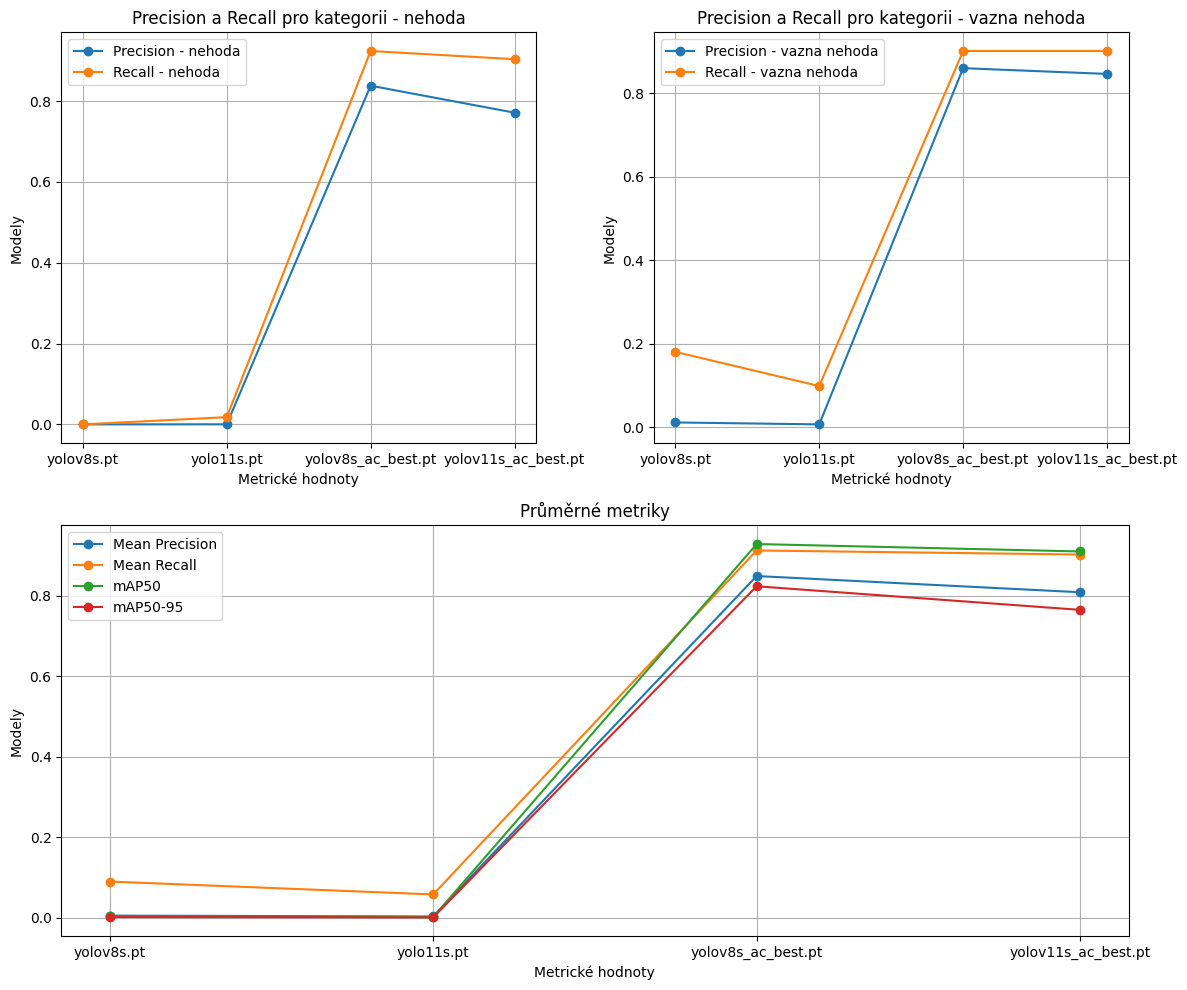

In [11]:
# List of model paths
models = [
    'yolov8s.pt',
    'yolo11s.pt',
    'yolov8s_ac_best.pt',
    'yolov11s_ac_best.pt'
]

plot_metrics(models, 'val')

Můžeme vidět, že přeténováním

### Architektura modelu

Model byl modifikován na základě původní architektury YOLOv8s. Následující tabulka shrnuje klíčové komponenty modelu:

| **Vrstva**   | **Parametry**             |
|--------------|---------------------------|
| SPPF         | `[512, 512, 5]`          |
| Detect       | `[2, [128, 256, 512]]`   |
| C2f          | Více konfigurací, např. `[64, 64, 1, True]` |

### Shrnutí rozdílů oproti YOLOv8s

Hlavní rozdíly oproti oficiální implementaci YOLOv8s zahrnují:
- **SPPF vrstva**: Změněna velikost jádra na 5 místo 3, což zvyšuje schopnost modelu zachytit větší kontext.
- **Detect vrstva**: Přizpůsobena pro dvě třídy (2) oproti standardním 80 třídám v COCO datasetu.
- **C2f bloky**: Optimalizované konfigurace bloků s různým počtem kanálů a opakováním.
- **Parametry**: Celkový počet parametrů modelu je 11,136,374.

Modifikovaná architektura je navržena pro specifické potřeby projektu a nabízí vyšší efektivitu pro cílovou úlohu detekce s dvěma třídami. Tyto úpravy optimalizují model jak z hlediska výpočetních požadavků, tak z hlediska přesnosti pro specifický dataset.


Následně jsme experimentovali s různými konfiguracemi váhových parametrů modelu (váhy pro loss bounding boxů, klasifikace a objektovost). Byly definovány čtyři různé konfigurace:
 - Default_Weights: Základní váhy pro všechny ztráty.
 - Increased_Box_Loss: Zvýšená váha pro loss bounding boxů.
 - Increased_Cls_Loss: Zvýšená váha pro klasifikační loss.
 - Increased_Obj_Loss: Zvýšená váha pro loss objektovosti.


\begin{array}{|c|c|c|c|}
\hline
\textbf{Name} & \textbf{Box} & \textbf{Cls} & \textbf{Obj} \\\\
\hline
Default\_Weights & 0.05 & 0.5 & 1.0 \\\\
\hline
Increased\_Box\_Loss & 0.1 & 0.5 & 1.0 \\\\
\hline
Increased\_Cls\_Loss & 0.05 & 0.6 & 1.0 \\\\
\hline
Increased\_Obj\_Loss & 0.05 & 0.5 & 1.2 \\\\
\hline
\end{array}



Každá z těchto konfigurací byla trénována na 100 epochách s počátčními vahami YOLOv8s varianty. Zde se můžeme podívat na vyhodnocení metrik precision, recall, mAP50 a mAP50-95.

Validating model: Default_Weights_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:36<00:00,  9.67s/it]


Validating model: Increased_Box_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:38<00:00,  9.84s/it]


Validating model: Increased_Cls_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:42<00:00, 10.22s/it]


Validating model: Increased_Obj_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:37<00:00,  9.74s/it]


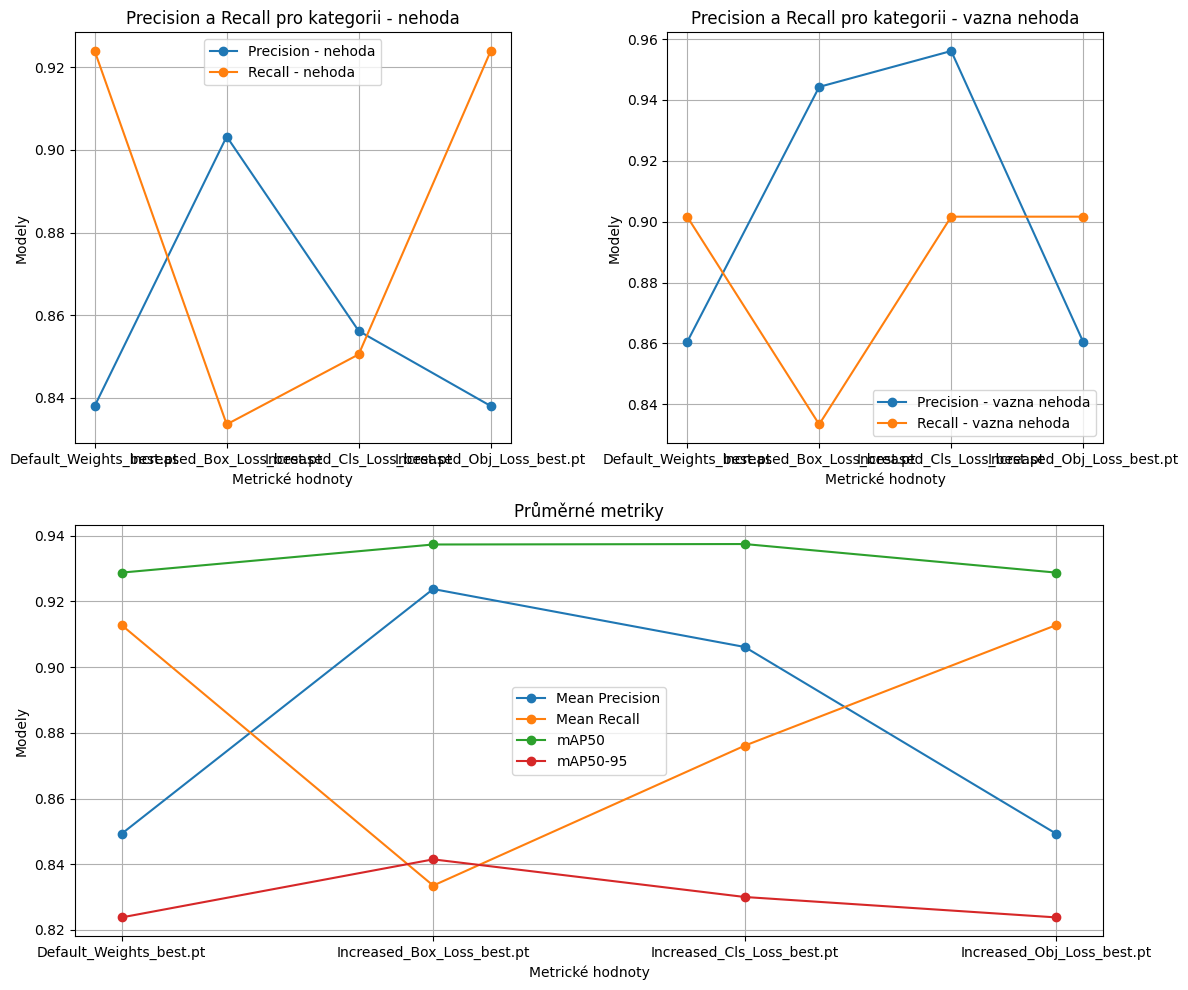

In [12]:
# List of model paths
models = [
    'Default_Weights_best.pt',
    'Increased_Box_Loss_best.pt',
    'Increased_Cls_Loss_best.pt',
    'Increased_Obj_Loss_best.pt'
]

plot_metrics(models, 'val')

Z grafů můžeme pozorovat, že změna váhy pro objectness loss se na výsledku modelu projeví jen minimálně. Změna při zvýšení váhy u box loss a clasification loss je zřetelnější. V našem případě chceme především zamezit tomu, že nehoda nebude detekována a na místo nevyrazí potřebná pomoc. Tedy preferujeme vyšší hodnotu recall, ale další důležitý rozhodovací paramter je pro nás poměr precision a recall. Přece jen nechceme se ani dostat do situace, kdy náš model způsobí mnoho falešných detekcí nehody, které zbytečně zaměstnají personál.

![PR_curve.png]()

# *Výsledky*

Na základě přechodzí úvahy jsme vybrali model s nastavením vah dle Increased_Cls_Loss. Nyní se podíváme na průběh jeho trénování. Z průběhu loss funkcí můžeme vidět, že train loss stále klesá, ale validation loss už se tolik nemění neboli je téměř konstantní pro všechny složky od osmdesáté epochy. Abych zabránili overfitování modelu, tak jsme trénování ukončily zde. Tento model byl poté integrován do GUI rozhraní, které umožňuje zpracování dat z CCTV kamer v reálném čase a upozornění uživatele na nehodu a následné jeho osobní vyhodnocení, jaké složky záchranného sytému je potřeba k nehodě přivolat.


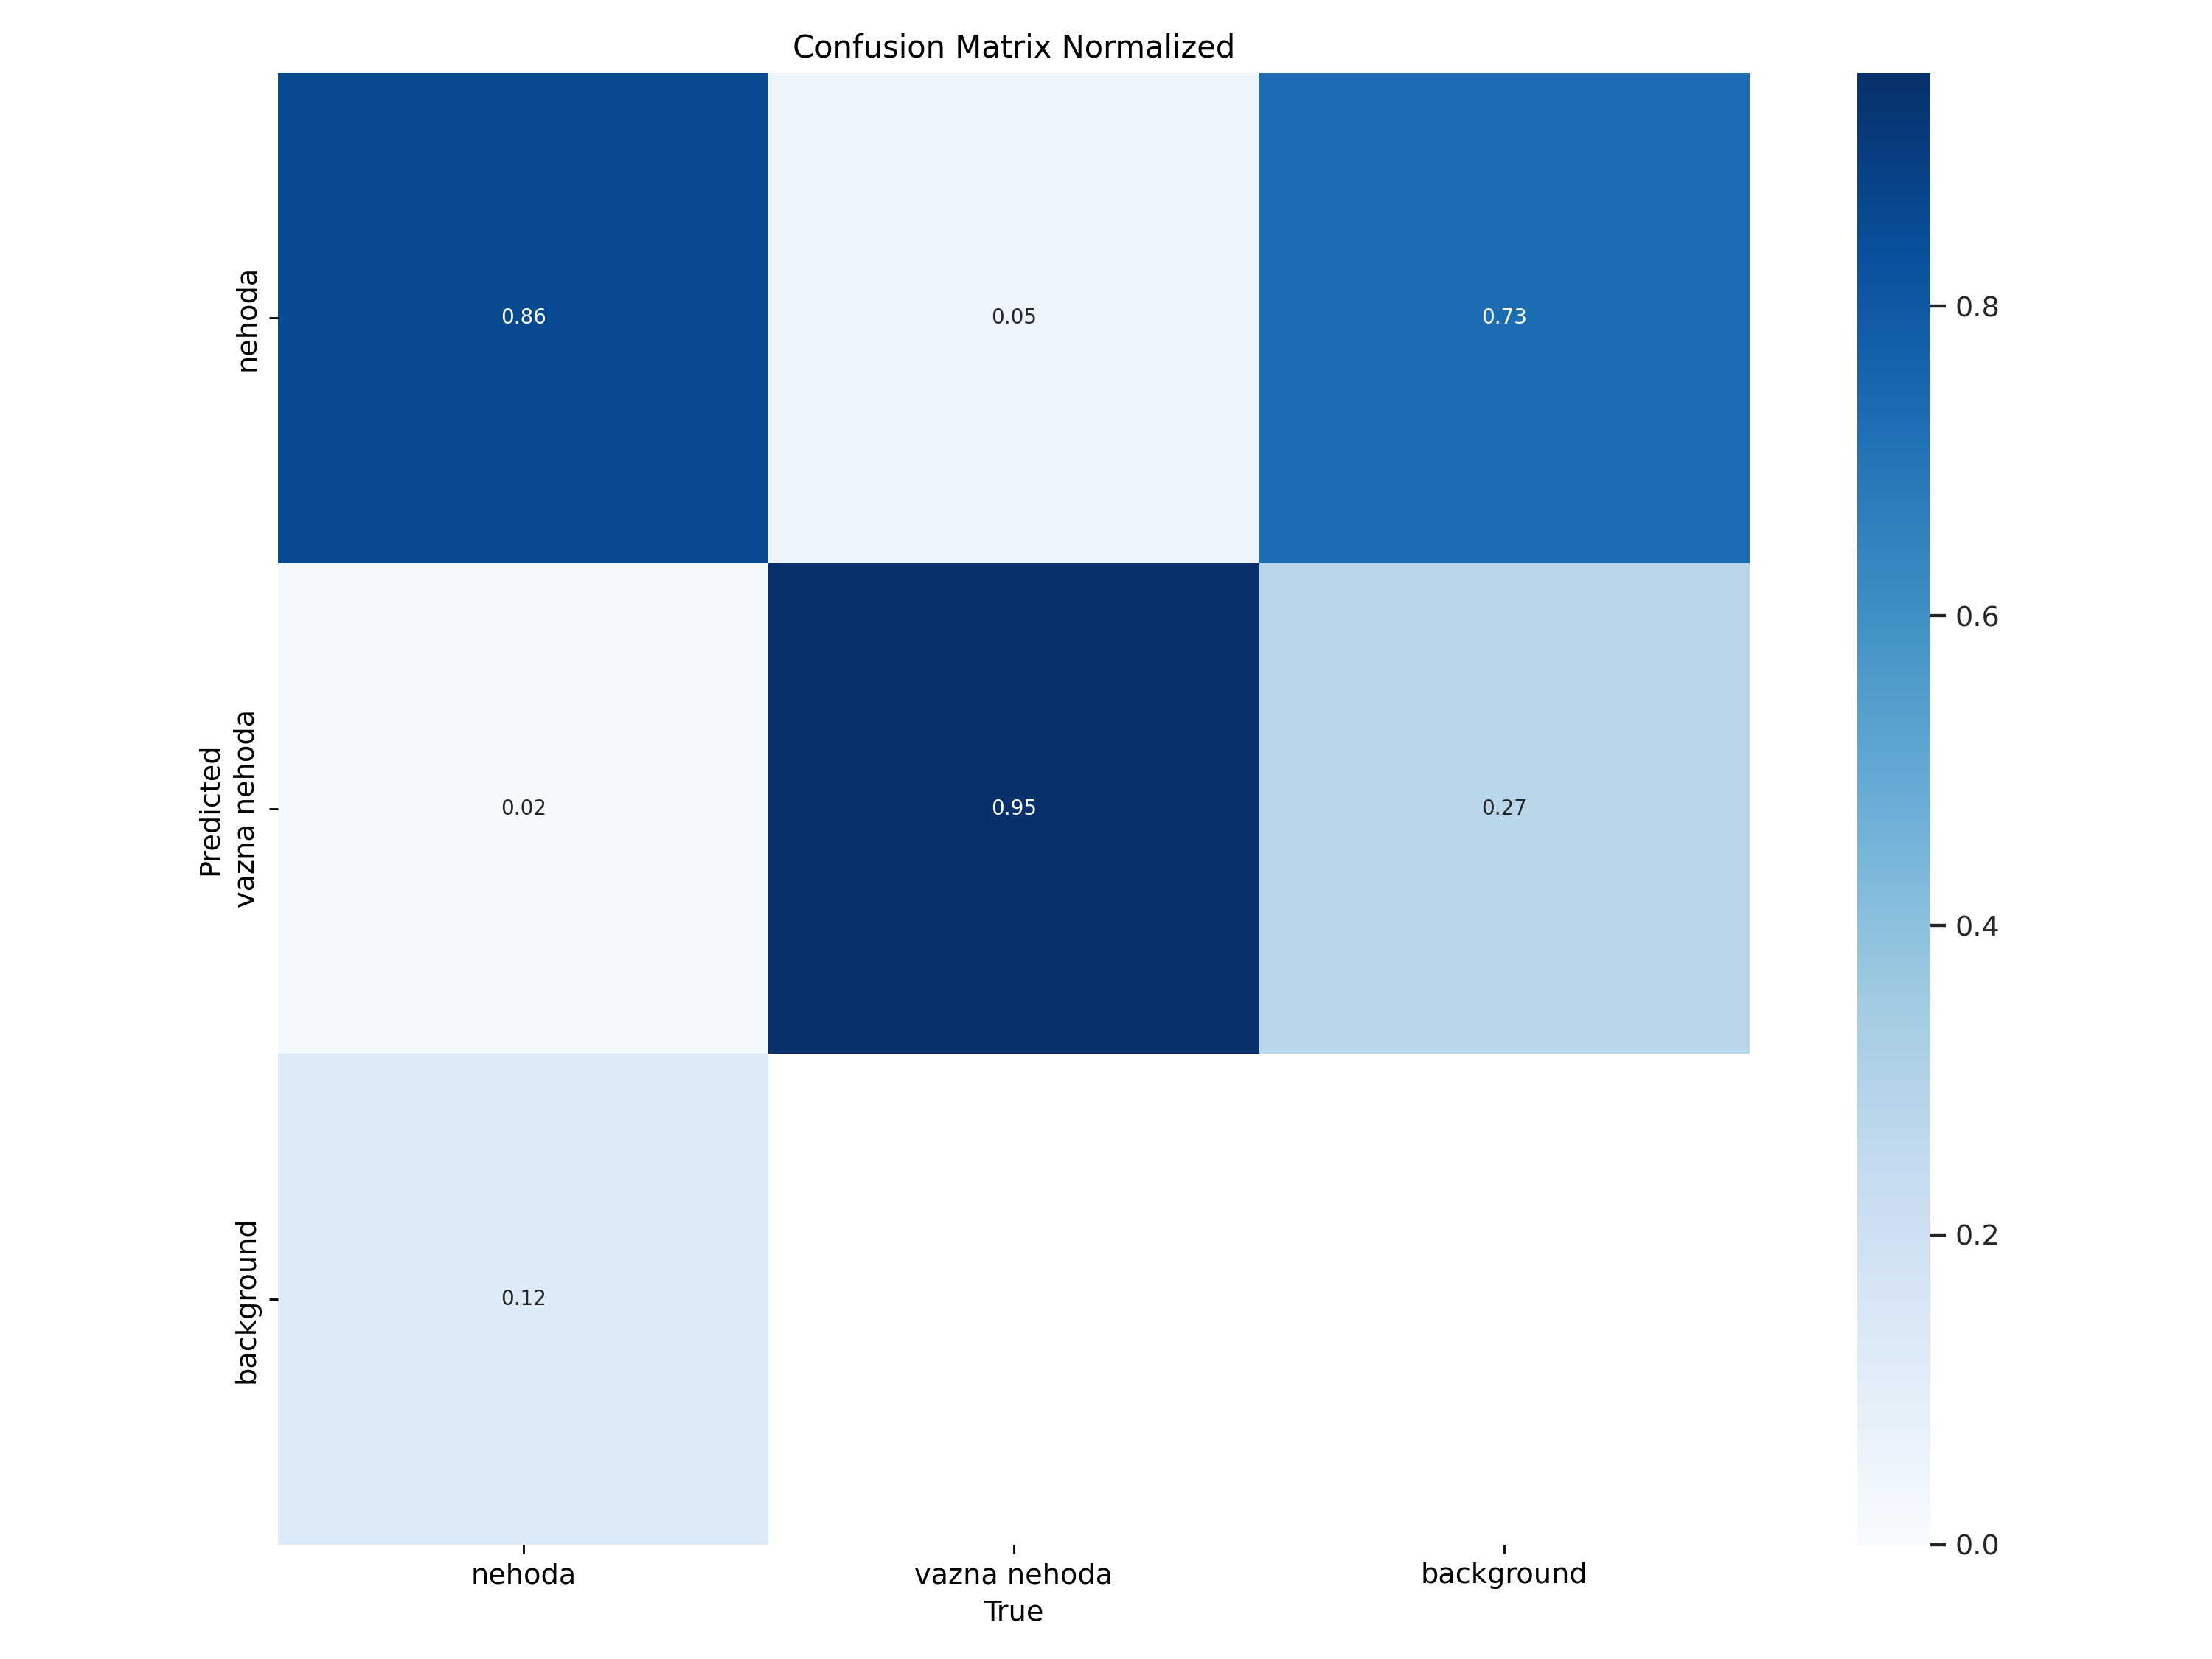

In [25]:
# Funkce pro zobrazení detekce na obrázcích
import glob
from PIL import Image

def zobraz_detekce_na_obrazcich(model, image_dir, num_images):
    image_paths = glob.glob(f"{image_dir}/*.jpg")[:num_images]
    for img_path in image_paths:
        results = model.predict(source=img_path, save=True)
        img = Image.open(results[0].path)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Detekovaná nehoda")
        plt.show()

In [26]:
# Načtení modelu
model = YOLO("/content/2024-final-julia-vendy/Increased_Cls_Loss_best.pt")
# Ukázka detekce na prvních 5 obrázcích
image_dir = "/content/Road-accident-victim-detection-2/test"
zobraz_detekce_na_obrazcich(model, image_dir, 1)

In [17]:
# Validate the model on the test set
metrics = model.val(data='/content/Road-accident-victim-detection-2/data.yaml', split='val', imgsz=640)

val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:41<00:00, 10.13s/it]


NameError: name 'metrics_data' is not defined

In [27]:
metrics.box.p
metrics.box.r
metrics.box.map50
metrics.box.map

0.8300220402191372

 Model dosáhl přesnosti 93.7% na confidenčním levelu 50% na validačním datasetu a dokázal spolehlivě rozpoznat nehody i na testovacích obrázcích.
 Níže uvádíme grafy a tabulky s metrikami modelu.

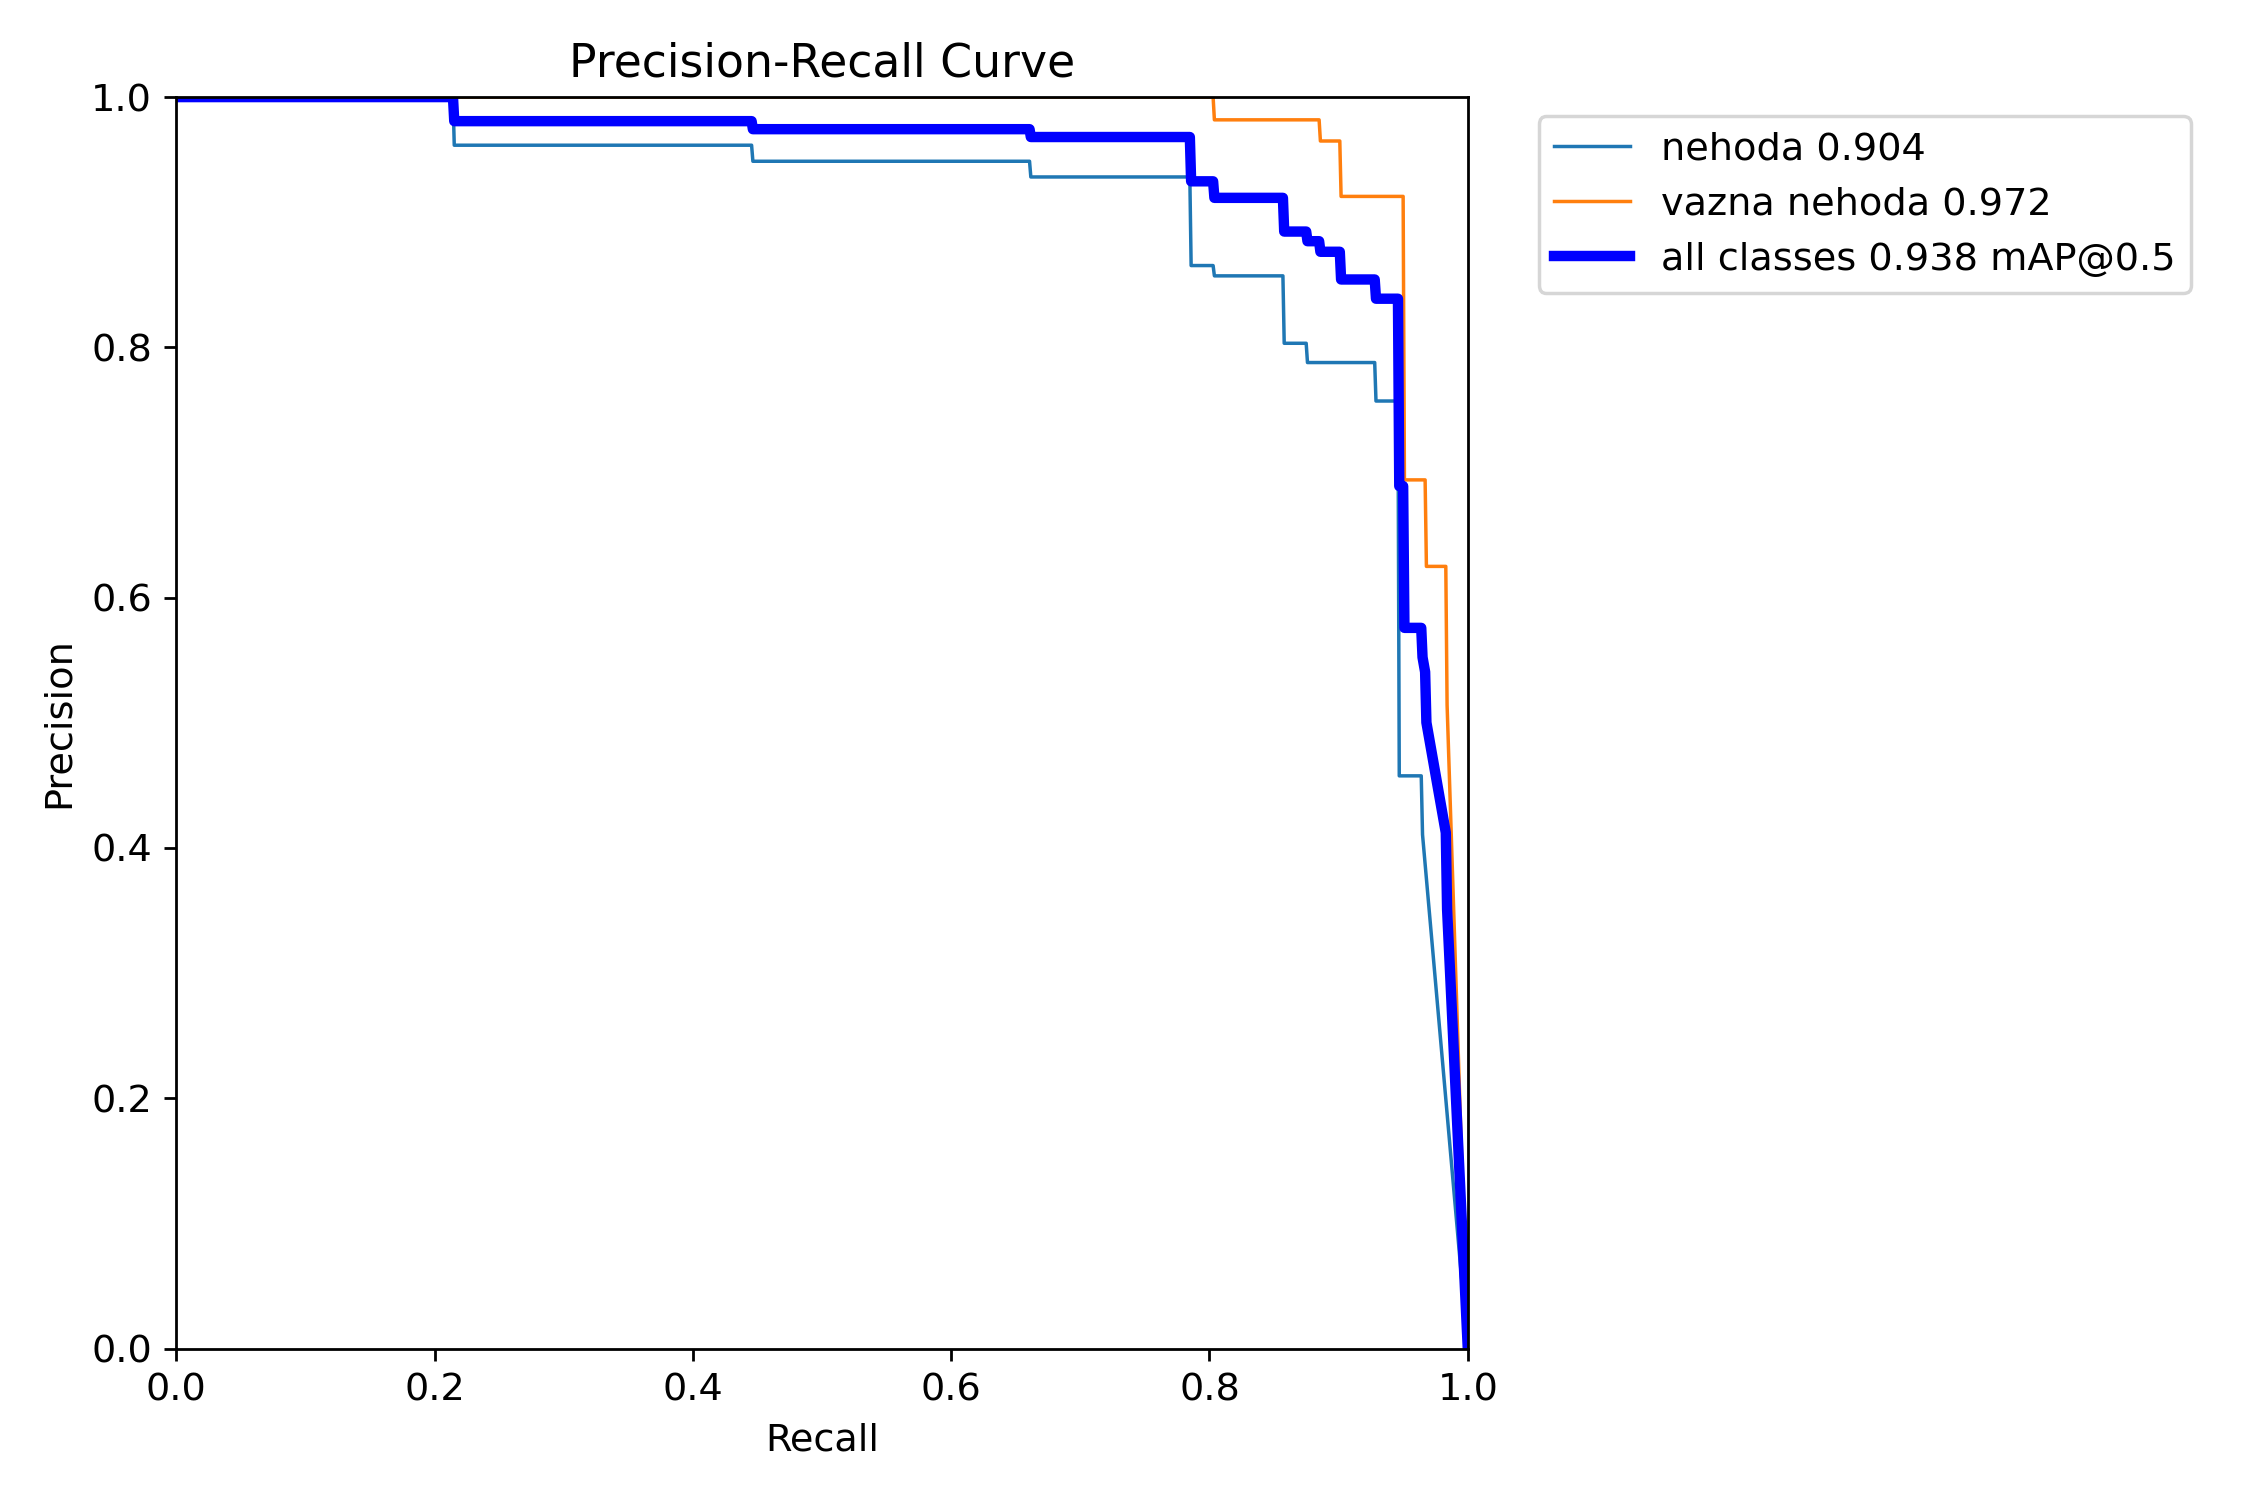

# *Ukázka použití v praxi*

In [ ]:

# Načtení GUI souboru
import sys
sys.path.append("su2projekt")
from gui_interface import start_gui

# Spuštění GUI
start_gui(model, video_dir=unzip_dir)


Tento přístup kombinuje flexibilitu experimentování s váhovými parametry, robustnost moderních metod strojového učení a praktickou implementaci do reálného prostředí. Výsledky ukazují, že model je schopen přesně detekovat nehody, což poskytuje základ pro jeho nasazení v praktických aplikacích.


#Závěr:
 Tento projekt demonstruje možnost využití hlubokého učení pro automatizaci detekce dopravních nehod. Mezi limity patří omezený dataset a citlivost modelu na světelné podmínky.

# Reference:
 - https://universe.roboflow.com/dronemed/road-accident-victim-detection/dataset/4
 - https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage